<a href="https://colab.research.google.com/github/xunan007/comp5511-lab/blob/main/Assignment_2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: The Connectionist Engine (Deep Learning)
**Course:** COMP5511 - Artificial Intelligence Concepts
**Goal:** Transition from "writing rules" to "learning from data".

In this assignment, we will explore two major paradigms of modern AI:
1. **Computer Vision:** Teaching a machine to recognize handwritten digits (MNIST).
2. **Natural Language Processing:** Fine-tuning a Large Language Model (LLM) to generate text.

In [ ]:
# Run this cell to import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import (
    Layout,
    Button,
    VBox,
    HBox,
    Output,
    Text,
    HTML,
    FloatSlider,
    IntSlider,
    ToggleButton,
    GridspecLayout,
)
from IPython.display import display, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn import svm
from sklearn.metrics import accuracy_score
import warnings
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

---
## Part 1: MNIST Digit Classification

### Background: From Rules to Data
In Assignment 1, we explicitly programmed the rules for our AI (e.g., "if block A is on block B...").
But how do we write rules for recognizing a handwritten '8'? It's too complex!
Instead, we use **Machine Learning**: we provide data (images of digits) and answers (labels), and the algorithm learns the rules.

### Inspecting the Data: What is a Tensor?
Before we train any models, let's look at the data. To a computer, an image is just a grid of numbers (a tensor).
Let's visualize a single digit and its underlying numerical representation.

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.34MB/s]


Label: 5
Image Tensor Shape: torch.Size([1, 28, 28]) -> (Channels, Height, Width)


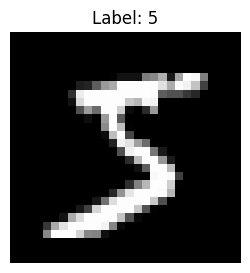


Raw Tensor Values (Center 10x10 patch):
0.0 0.6 1.0 0.4                        
    0.5 1.0 0.7 0.0                    
    0.0 0.7 1.0 0.3                    
        0.1 0.9 0.9 0.6 0.4 0.0        
            0.3 0.9 1.0 1.0 0.5 0.1    
                0.2 0.7 1.0 1.0 0.6 0.1
                    0.1 0.4 1.0 1.0 0.7
                            1.0 1.0 1.0
                0.2 0.5 0.7 1.0 1.0 0.8
        0.2 0.6 0.9 1.0 1.0 1.0 1.0 0.7


In [ ]:
# 1. Load the MNIST dataset
print("Loading MNIST dataset...")
# We use a transform to convert images to PyTorch tensors and normalize them
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Get the first image and label from the training set
sample_image, sample_label = train_dataset[0]

print(f"Label: {sample_label}")
print(f"Image Tensor Shape: {sample_image.shape} -> (Channels, Height, Width)")

# Display the image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Label: {sample_label}")
plt.axis("off")
plt.show()

# Show a small 10x10 patch of the tensor values (the center of the image)
print("\nRaw Tensor Values (Center 10x10 patch):")
patch = sample_image.squeeze()[10:20, 10:20]
# Print with formatting
for row in patch:
    print(" ".join([f"{val:.1f}" if val > 0 else "   " for val in row]))

### Task 1.1: Stage 1 - Classic ML (SVM) & Feature Engineering
**Goal:** Train a Support Vector Machine (SVM) to classify digits.

**The Challenge:** Raw pixels are sometimes hard for classic ML models to understand. We can help the model by extracting "features" (e.g., how much ink is in the top half vs bottom half).

**Instructions:**
1. Tune the SVM hyperparameters (`C` and `kernel`).
2. Implement a simple feature extraction function.

In [ ]:
# Use a small subset for SVM to keep training fast in the lab (1000 samples)
# HINT: Try increasing this to 5000 or 10000. What happens to the training time?
# Does the accuracy improve enough to justify the wait?
X_train_raw = train_dataset.data[:1000].numpy()
y_train_svm = train_dataset.targets[:1000].numpy()
X_test_raw = test_dataset.data[:200].numpy()
y_test_svm = test_dataset.targets[:200].numpy()


def extract_features(images):
    """
    STUDENT TASK 1.1a: Feature Engineering
    Currently, this function just flattens the 28x28 image into a 784-1D array.
    Can you add a feature? For example, the average pixel intensity of the image.
    """
    num_samples = images.shape[0]
    # Flatten images: (N, 28, 28) -> (N, 784)
    flattened = images.reshape(num_samples, -1) / 255.0

    # --- YOUR CODE HERE (Optional: Add custom features) ---
    # Example: avg_intensity = np.mean(flattened, axis=1, keepdims=True)
    # features = np.hstack((flattened, avg_intensity))
    # TODO: Create your feature set (e.g., flattened only, or flattened + custom features)
    features = flattened
    # ------------------------------------------------------
    return features


X_train_features = extract_features(X_train_raw)
X_test_features = extract_features(X_test_raw)

# STUDENT TASK 1.1b: Tune the SVM Hyperparameters
# Try changing C (e.g., 0.1, 1, 10) and kernel (e.g., 'linear', 'rbf', 'poly')
# --- YOUR CODE HERE ---
# TODO: Tune these hyperparameters
svm_model = svm.SVC(C=1.0, kernel="rbf", probability=True)
# ----------------------

print("Training SVM... (This might take 10-20 seconds)")
svm_model.fit(X_train_features, y_train_svm)
svm_preds = svm_model.predict(X_test_features)
print(f"SVM Accuracy: {accuracy_score(y_test_svm, svm_preds) * 100:.2f}%")

Training SVM... (This might take 10-20 seconds)
SVM Accuracy: 93.00%


### The Digit Guessing Game (SVM)
Let's test your SVM model! Use the slider to select an image from the test set and see what the SVM predicts.

In [ ]:
# Interactive SVM Tester
out_svm = Output()
img_slider = IntSlider(value=0, min=0, max=499, description="Test Image:")
btn_predict_svm = Button(description="Predict with SVM")


def predict_svm(_):
    with out_svm:
        clear_output()
        idx = img_slider.value
        img = X_test_raw[idx]

        # Display image
        plt.figure(figsize=(2, 2))
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.show()

        # Predict
        features = extract_features(np.array([img]))
        pred = svm_model.predict(features)[0]
        probs = svm_model.predict_proba(features)[0]
        confidence = probs[pred] * 100

        print(f"SVM Prediction: {pred}")
        print(f"Confidence: {confidence:.2f}%")


btn_predict_svm.on_click(predict_svm)
display(
    VBox(
        [
            HTML("<b>Select an image to test:</b>"),
            HBox([img_slider, btn_predict_svm]),
            out_svm,
        ]
    )
)

### Task 1.2: Stage 2 - Deep Learning (CNN) & Feature Maps
**Goal:** Build a Convolutional Neural Network (CNN) that learns its own features.

**The Challenge:** Complete the CNN architecture. Unlike SVMs where we manually engineer features, CNNs use convolutional layers to automatically learn spatial hierarchies of features (edges -> shapes -> digits).

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # STUDENT TASK 1.2a: Define the CNN layers
        # We need:
        # 1. A Convolutional layer (in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # 2. A ReLU activation function
        # 3. A Max Pooling layer (kernel_size=2, stride=2)
        # 4. A second Convolutional layer (in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # 5. A Fully Connected (Linear) layer mapping to 10 classes

        # --- YOUR CODE HERE ---
        self.conv1 = None
        self.relu = None
        self.pool = None
        self.conv2 = None
        self.fc1 = None
        # ----------------------

    def forward(self, x):
        # STUDENT TASK 1.2b: Connect the layers
        # Pass 'x' through conv1 -> relu -> pool -> conv2 -> relu -> pool.
        # Then flatten the tensor and pass it through fc1.

        # --- YOUR CODE HERE ---
        raise NotImplementedError("TODO: Implement the CNN forward pass")
        # ----------------------
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cnn_model = SimpleCNN().to(device)

# Optimize with torch.compile if available
if hasattr(torch, 'compile') and device.type == 'cuda':
    try:
        print("Compiling model with torch.compile for faster training...")
        cnn_model = torch.compile(cnn_model)
    except Exception as e:
        print(f"torch.compile failed, proceeding without it: {e}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training Loop
print("Training CNN... (Training on the full dataset for 3 epochs)")
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
cnn_model.train()

losses = []
epochs = 3
for epoch in range(epochs):
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")
    for i, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
            losses.append(loss.item())
print("CNN Training Complete!")

# Plot training loss
plt.plot(losses)
plt.title("CNN Training Loss")
plt.xlabel("Tens of Batches")
plt.ylabel("Loss")
plt.show()

Using device: cpu


ValueError: optimizer got an empty parameter list

### Visualizing Feature Maps (The "Mind's Eye" of the CNN)
What does the CNN actually "see"? Let's extract the outputs of the first convolutional layer.

In [ ]:
def visualize_feature_maps(model, image_tensor):
    """
    STUDENT TASK 1.2c: Extract and plot the feature maps.
    """
    model.eval()
    with torch.no_grad():
        # Add batch dimension and move to device
        img_input = image_tensor.unsqueeze(0).to(device)

        # --- YOUR CODE HERE ---
        # Pass the image through the first conv layer and ReLU
        # Note: If using torch.compile, the original model is accessed via model._orig_mod
        raise NotImplementedError("TODO: Extract feature maps from the first conv layer")
        # ----------------------

        # Plot the first 8 feature maps
        fig, axes = plt.subplots(1, 8, figsize=(16, 2))
        for i in range(8):
            axes[i].imshow(feature_maps[0, i].cpu().numpy(), cmap="viridis")
            axes[i].axis("off")
            axes[i].set_title(f"Filter {i}")
        plt.show()


# Test visualization
sample_img_tensor = train_dataset[0][0]  # Get first image tensor
print("Original Image:")
plt.figure(figsize=(2, 2))
plt.imshow(sample_img_tensor.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

print("Feature Maps (Activations of Conv1):")
visualize_feature_maps(cnn_model, sample_img_tensor)

### The Digit Painter (CNN)
Draw a digit on the 14x14 grid below and see what the CNN predicts!

**HINT:** Try drawing something that is *not* a digit (like a smiley face or a square).
What does the CNN predict? Why do you think it makes that prediction?
(Remember, the CNN *must* choose one of the 10 classes it was trained on!)

In [ ]:
# Interactive Drawing Canvas using ToggleButtons
GRID_SIZE = 14
draw_grid = GridspecLayout(GRID_SIZE, GRID_SIZE, width="280px", height="280px")

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        btn = ToggleButton(
            value=False,
            layout=Layout(width="auto", height="auto", margin="0px", padding="0px"),
        )
        # Simple styling to make it look like a pixel
        btn.style.button_color = "white"

        def on_click(change, btn=btn):
            btn.style.button_color = "black" if change["new"] else "white"

        btn.observe(on_click, "value")
        draw_grid[i, j] = btn

btn_predict_draw = Button(description="Predict Drawing", button_style="success")
btn_clear_draw = Button(description="Clear", button_style="warning")
out_draw = Output()


def get_drawn_image():
    # Convert grid to 14x14 numpy array, then resize to 28x28
    img = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            if draw_grid[i, j].value:
                img[i, j] = 1.0
    # Simple upscale to 28x28 by repeating pixels
    img_28 = np.repeat(np.repeat(img, 2, axis=0), 2, axis=1)
    return img_28


def predict_drawing(_):
    with out_draw:
        clear_output()
        img_np = get_drawn_image()
        img_tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(
            0
        )  # (1, 28, 28)

        cnn_model.eval()
        with torch.no_grad():
            img_tensor_device = img_tensor.to(device)
            output = cnn_model(img_tensor_device.unsqueeze(0))  # (1, 1, 28, 28)
            probs = torch.softmax(output, dim=1)[0]
            pred = torch.argmax(probs).item()
            confidence = probs[pred].item() * 100

        print(f"CNN Prediction: {pred}")
        print(f"Confidence: {confidence:.2f}%")
        print("\nFeature Maps for your drawing:")
        visualize_feature_maps(cnn_model, img_tensor)


def clear_drawing(_):
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            draw_grid[i, j].value = False
            draw_grid[i, j].style.button_color = "white"
    with out_draw:
        clear_output()


btn_predict_draw.on_click(predict_drawing)
btn_clear_draw.on_click(clear_drawing)

display(
    VBox(
        [
            HTML("<b>Draw a digit (0-9) by clicking the grid:</b>"),
            draw_grid,
            HBox([btn_predict_draw, btn_clear_draw]),
            out_draw,
        ]
    )
)

### Task 1.3: Stage 3 - The Scalability Test (CIFAR-10)
**Goal:** Compare how SVM and CNN handle harder, larger datasets.

**The Challenge:** MNIST is too easy. Let's try CIFAR-10, a dataset of 32x32 color images in 10 classes (dogs, cats, cars, etc.).
Classic ML algorithms like SVM struggle with the high dimensionality (3x32x32 = 3072 features) and complex spatial relationships.
Let's inspect the dataset, then train both models and compare.

In [ ]:
import time

print("Loading CIFAR-10 dataset...")
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
cifar_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)
cifar_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_cifar)

# Inspecting CIFAR-10
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("\nInspecting CIFAR-10 Dataset:")
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i in range(5):
    img, label = cifar_train[i]
    # Un-normalize and convert to numpy for plotting
    img_np = img.numpy().transpose((1, 2, 0))
    img_np = img_np * 0.5 + 0.5
    axes[i].imshow(img_np)
    axes[i].set_title(cifar_classes[label])
    axes[i].axis('off')
plt.show()

print("Preparing subsets...")
# SVM is CPU-bound and slow, so we use a small subset (2,000 samples)
X_train_cifar_svm = cifar_train.data[:2000]
y_train_cifar_svm = np.array(cifar_train.targets)[:2000]
X_test_cifar_svm = cifar_test.data[:500]
y_test_cifar_svm = np.array(cifar_test.targets)[:500]

# Flatten for SVM: (N, 32, 32, 3) -> (N, 3072)
X_train_cifar_flat = X_train_cifar_svm.reshape(2000, -1) / 255.0
X_test_cifar_flat = X_test_cifar_svm.reshape(500, -1) / 255.0

# 1. Train SVM on CIFAR-10
print("\n--- Training SVM on CIFAR-10 (2,000 samples) ---")
svm_cifar = svm.SVC(C=1.0, kernel="rbf")
start_time = time.time()
svm_cifar.fit(X_train_cifar_flat, y_train_cifar_svm)
svm_time = time.time() - start_time
svm_acc = accuracy_score(y_test_cifar_svm, svm_cifar.predict(X_test_cifar_flat))
print(f"SVM Training Time: {svm_time:.2f} seconds")
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

# 2. Train CNN on CIFAR-10
print("\n--- Training CNN on CIFAR-10 (Full 50,000 samples) ---")
class CIFARCNN(nn.Module):
    def __init__(self):
        super(CIFARCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_cifar = CIFARCNN().to(device)
if hasattr(torch, 'compile') and device.type == 'cuda':
    try:
        cnn_cifar = torch.compile(cnn_cifar)
    except:
        pass

optimizer_cifar = optim.Adam(cnn_cifar.parameters(), lr=0.001)
criterion_cifar = nn.CrossEntropyLoss()

# Use the full dataset and a larger batch size for the GPU
cifar_loader = torch.utils.data.DataLoader(cifar_train, batch_size=128, shuffle=True)

start_time = time.time()
cnn_cifar.train()
epochs_cifar = 5
for epoch in range(epochs_cifar):  # 5 epochs for better learning
    pbar = tqdm(cifar_loader, desc=f"Epoch {epoch+1}/{epochs_cifar}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer_cifar.zero_grad()
        outputs = cnn_cifar(images)
        loss = criterion_cifar(outputs, labels)
        loss.backward()
        optimizer_cifar.step()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
cnn_time = time.time() - start_time

# Evaluate CNN on the full test set
cnn_cifar.eval()
correct = 0
total = 0
cifar_test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=128)
with torch.no_grad():
    for images, labels in cifar_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_cifar(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
cnn_acc = correct / total

print(f"CNN Training Time ({epochs_cifar} Epochs): {cnn_time:.2f} seconds")
print(f"CNN Accuracy: {cnn_acc * 100:.2f}%")
print(
    "\nNotice how the CNN significantly outperforms the SVM on this harder dataset, and its batch-based training scales efficiently!"
)

### Task 1.4: Stage 4 - Vision Transformers (ViT)
**Goal:** Build a simple Vision Transformer to see how attention processes images.

**The Challenge:** CNNs look at local patches. Transformers treat the image as a sequence of patches (like words in a sentence) and use Self-Attention to let patches "look" at any other patch globally. Let's build a tiny ViT for MNIST and compare!

In [ ]:
import torch.nn.functional as F


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, emb_size=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        # STUDENT TASK 1.4a: Implement Patch Embedding
        # Extract patches of size 8x8 using a Conv2d layer
        # --- YOUR CODE HERE ---
        self.projection = nn.Conv2d(
            in_channels, emb_size, kernel_size=patch_size, stride=patch_size
        )
        # ----------------------

    def forward(self, x):
        # We start with (Batch, Channels, Height, Width)
        x = self.projection(x)  # (B, emb_size, H_p, W_p)
        x = x.flatten(2)  # (B, emb_size, H_p * W_p)
        x = x.transpose(1, 2)  # (B, num_patches, emb_size)
        return x


class SimpleViT(nn.Module):
    def __init__(
        self, in_channels=3, patch_size=8, emb_size=64, img_size=32, num_classes=10
    ):
        super().__init__()
        self.patch_emb = PatchEmbedding(in_channels, patch_size, emb_size, img_size)

        # Calculate number of patches: (32 // 8) * (32 // 8) = 16 patches
        num_patches = (img_size // patch_size) ** 2

        # Positional Embedding (1 cls token + 16 patches = 17)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_emb = nn.Parameter(torch.randn(1, num_patches + 1, emb_size))

        # STUDENT TASK 1.4b: Setup Transformer and MLP
        # Create a TransformerEncoderLayer and a TransformerEncoder
        # --- Important: core vit model ---
        # Note: batch_first=True makes standard (Batch, Seq, Features) easier
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size, nhead=8, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Predict class from the 64-dim output of the CLS token
        self.mlp_head = nn.Linear(emb_size, num_classes)
        # ----------------------

    def forward(self, x, return_attention=False):
        B = x.shape[0]
        x = self.patch_emb(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, 17, 64)
        x = x + self.pos_emb

        # If we just want the final output
        if not return_attention:
            x = self.transformer(x)
            cls_output = x[:, 0]
            return self.mlp_head(cls_output)

        # If we want to extract attention maps, we have to do it manually for standard PyTorch Transformer
        # We'll pass through layer 1, and manually get attention from layer 1 or layer 2
        # (For simplicity in this lab, we just return the full sequence output to analyze)
        x = self.transformer(x)
        return x


vit_model = SimpleViT().to(device)

if hasattr(torch, "compile") and device.type == "cuda":
    try:
        vit_model = torch.compile(vit_model)
    except:
        pass

optimizer_vit = optim.Adam(vit_model.parameters(), lr=0.001)
criterion_vit = nn.CrossEntropyLoss()

# Training Loop for ViT on CIFAR-10
print("\n--- Training ViT on CIFAR-10 (15 epochs) ---")
vit_model.train()
vit_losses = []
# ViT is hard to train
epochs_vit = 20
start_time_vit = time.time()

for epoch in range(epochs_vit):
    pbar = tqdm(
        enumerate(cifar_loader),
        total=len(cifar_loader),
        desc=f"Epoch {epoch + 1}/{epochs_vit}",
    )
    for i, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer_vit.zero_grad()
        outputs = vit_model(images)
        loss = criterion_vit(outputs, labels)
        loss.backward()
        optimizer_vit.step()

        if i % 10 == 0:
            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
            vit_losses.append(loss.item())
vit_time = time.time() - start_time_vit

# Evaluate ViT on CIFAR-10
vit_model.eval()
correct_vit = 0
total_vit = 0
with torch.no_grad():
    for images, labels in cifar_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_vit += labels.size(0)
        correct_vit += (predicted == labels).sum().item()
vit_acc = correct_vit / total_vit

print(f"ViT Training Time ({epochs_vit} Epochs): {vit_time:.2f} seconds")
print(f"ViT Accuracy: {vit_acc * 100:.2f}%")

In [ ]:
def visualize_vit_patches(model, image_tensor, label):
    """
    STUDENT TASK 1.4c: Visualize the importance of each patch
    """
    model.eval()
    with torch.no_grad():
        img_input = image_tensor.unsqueeze(0).to(device)

        # Get the sequence output (B, 17, emb_size)
        base_model = model._orig_mod if hasattr(model, "_orig_mod") else model
        seq_out = base_model(img_input, return_attention=True)

        # Get the prediction
        logits = base_model(img_input)
        _, predicted = torch.max(logits, 1)
        pred_label = predicted.item()

        # Extract the 16 patches (ignore idx 0 which is CLS) -> (1, 16, emb_size)
        patches_out = seq_out[0, 1:]

        # Take the L2 norm of the emb_size-dim vector for each patch to measure its "activation/importance"
        patch_importance = torch.norm(patches_out, dim=1).cpu().numpy()

        # Reshape to a 4x4 grid (since 32/8 = 4)
        patch_importance = patch_importance.reshape(4, 4)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    true_class = cifar_classes[label]
    pred_class = cifar_classes[pred_label]
    fig.suptitle(f"True: {true_class} | Predicted: {pred_class}", fontsize=14)

    # Plot Original
    img_np = image_tensor.cpu().numpy().transpose((1, 2, 0))
    img_np = img_np * 0.5 + 0.5  # Un-normalize
    img_np = np.clip(img_np, 0, 1)

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Plot Patch Importance Heatmap (interpolated to 32x32 for overlay)
    import cv2

    heatmap = cv2.resize(patch_importance, (32, 32), interpolation=cv2.INTER_NEAREST)
    axes[1].imshow(img_np, alpha=0.5)
    img_plot = axes[1].imshow(heatmap, cmap="jet", alpha=0.5)
    axes[1].set_title("Patch Importance Heatmap")
    axes[1].axis("off")
    plt.colorbar(img_plot, ax=axes[1])
    plt.show()


# Test visualization
print("ViT Patch Importance:")
sample_cifar_img_tensor, sample_label = cifar_test[1234]
visualize_vit_patches(vit_model, sample_cifar_img_tensor, sample_label)

---
## Part 2: Fine-Tuning a Modern Mini-LLM

### Background: Generative AI & Transformers
In this section, we move from classifying images to generating text. We will use a pre-trained **Qwen3.5** model (a highly capable, modern 0.8-billion parameter instruction-tuned model, which acts like a tiny ChatGPT).

In [ ]:
# Install transformers if not present (uncomment in Colab)
!pip install transformers

from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading Qwen3.5 model... (This may take a minute to download weights)")
# We use a modern instruction-tuned model
model_id = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
# Ensure padding token is set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

llm_model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
llm_model.eval()

### Exploring Qwen3.5: What can an Instruction Model do?
Unlike older models (like GPT-2) that just randomly continued sentences, modern "Instruct" models are trained to follow a conversation structure: `User: <prompt> -> Assistant: <response>`.
We use a standard Hugging Face feature called `apply_chat_template` to format our prompt automatically so the model knows we are the User asking a question.

In [ ]:
def simple_generate(prompt, max_length=50):
    print(f"User Prompt: {prompt}")
    print("-" * 20)

    # Format the prompt as a conversation
    messages = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_length,
            do_sample=False,  # Deterministic output for now
            pad_token_id=tokenizer.eos_token_id,
        )

    # Extract only the newly generated tokens (ignore the prompt)
    generated_ids = outputs[0][inputs.input_ids.shape[1] :]
    print("Assistant:\n" + tokenizer.decode(generated_ids, skip_special_tokens=True))
    print("=" * 40 + "\n")


# Use Case 1: Creative Writing
simple_generate("Write a one-sentence story about a futuristic city.")

# Use Case 2: Factual Knowledge
simple_generate("What is the capital of France?")

# Use Case 3: Simple Logic/Code
simple_generate("Write a Python function to add two numbers.")

# STUDENT TASK: Try your own prompt!
# HINT: Try asking it a trick question, or ask it to summarize a concept.
# simple_generate("YOUR PROMPT HERE")

### Task 2.1: Stage 1 - Inference & Temperature Sampling
**Goal:** Generate text and control its "creativity".

**The Challenge:** Language models output a probability distribution over the vocabulary. If we always pick the most likely word, the text is boring. We use **Temperature** to flatten or sharpen this distribution.
*   **High Temperature (>1.0):** More random, creative.
*   **Low Temperature (<1.0):** More predictable, safe.

In [ ]:
def generate_text(prompt, max_length=30, temperature=1.0, model=None):
    if model is None:
        model = llm_model

    messages = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    input_ids = inputs.input_ids

    print(f"Prompt: {prompt}")

    generated_tokens = []
    with torch.no_grad():
        for _ in range(max_length):
            outputs = model(input_ids)
            # Get the logits for the last token
            next_token_logits = outputs.logits[0, -1, :]

            # STUDENT TASK 2.1: Implement Temperature Scaling
            # Formula: scaled_logits = logits / temperature
            # --- YOUR CODE HERE ---

            # ----------------------

            # Convert to probabilities
            probs = torch.softmax(scaled_logits, dim=-1)

            # Sample from the distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Append to input_ids for the next iteration
            input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
            generated_tokens.append(next_token.item())

            # Stop if the model generates the end-of-sequence token (e.g. <|im_end|>)
            word = tokenizer.decode(next_token.item())
            if next_token.item() == tokenizer.eos_token_id or "<|im_end|>" in word:
                break

    # Safely decode the entire sequence once at the end
    # This prevents sub-word formatting bugs and Jupyter frontend line-break issues
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    print(f"Assistant: {response}\n")


# Test Generation
print("--- Low Temperature (Predictable) ---")
print("Round 1")
generate_text(
    "Explain artificial intelligence in one sentence.", max_length=100, temperature=0.01
)
print("Round 2")
generate_text(
    "Explain artificial intelligence in one sentence.", max_length=100, temperature=0.01
)

print("\n--- High Temperature (Creative/Chaotic) ---")
print("Round 1")
generate_text(
    "Explain artificial intelligence in one sentence.", max_length=100, temperature=1.2
)
print("Round 2")
generate_text(
    "Explain artificial intelligence in one sentence.", max_length=100, temperature=1.2
)

### Task 2.2: Stage 2 - Custom Training Loop (Instruction Fine-Tuning)
**Goal:** Teach the model a new persona (Emoji Master!).

**The Challenge:** The model already knows how to answer questions politely. Let's explicitly fine-tune it on a tiny custom dataset to make it answer using primarily emojis and emoticons! We write the PyTorch training loop to update the model's weights.

In [ ]:
# A tiny instruction dataset for fine-tuning our Emoji Persona
emoji_dataset = [
    ("Hello!", "👋😄"),
    ("How are you?", "👍😊✨"),
    ("What is your name?", "🤖💬"),
    ("Where are you going?", "🚶‍♂️➡️🏠"),
    ("What's your favorite food?", "🍔🍕😋"),
    ("Can you help me?", "🤝✅"),
    ("What is a computer?", "💻🖥️🖱️"),
    ("Who is your best friend?", "👨‍💻❤️👩‍💻"),
    ("What do you do for fun?", "🎮🕹️😎"),
    ("Goodbye!", "👋👋😢"),
]

# Convert the dataset into the Chat format the model expects
training_texts = []
for user_text, emoji_text in emoji_dataset:
    chat = [
        {"role": "user", "content": user_text},
        {"role": "assistant", "content": emoji_text},
    ]
    formatted_chat = tokenizer.apply_chat_template(chat, tokenize=False)
    training_texts.append(formatted_chat)

# Prepare data for PyTorch
encoded_inputs = tokenizer(
    training_texts, padding=True, truncation=True, return_tensors="pt"
).to(device)

import copy
print("Cloning original model for fine-tuning...")
fine_tuned_model = copy.deepcopy(llm_model)

# Setup Optimizer
optimizer_ft = optim.AdamW(fine_tuned_model.parameters(), lr=1e-4)

print("Starting Fine-Tuning... (Teaching the model to speak in Emoji)")
fine_tuned_model.train()
epochs = 8

for epoch in range(epochs):
    # STUDENT TASK 2.2: Complete the training loop
    # 1. Clear gradients (optimizer_ft.zero_grad())
    # 2. Forward pass (pass input_ids, attention_mask, and labels to the model)
    #    Note: For language modeling, target labels are the same as input_ids.
    # 3. Calculate loss (outputs.loss)
    # 4. Backward pass (loss.backward())
    # 5. Update weights (optimizer_ft.step())

    # --- YOUR CODE HERE ---
    optimizer_ft.zero_grad()

    outputs = fine_tuned_model(
        input_ids=...,
        attention_mask=...,
        labels=...,  # Shifts internally to predict next word
    )

    loss = ...
    loss.backward()
    optimizer_ft.step()
    # ----------------------

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print("Fine-Tuning Complete!")

# Test the fine-tuned model
fine_tuned_model.eval()

### Comparing Original vs. Fine-Tuned Model
Let's see the exact same prompt processed by the model before and after we fine-tuned it!

In [ ]:
print("\n--- Original Model ---")
generate_text("What is your name?", max_length=30, temperature=0.7, model=llm_model)

print("\n--- Fine-Tuned Emoji Model ---")
generate_text("What is your name?", max_length=30, temperature=0.7, model=fine_tuned_model)

### Interactive Chatbot Interface
Let's wrap our model in a simple UI so you can chat with it!

In [ ]:
out_chat = Output()
text_prompt = Text(placeholder="Type a prompt here...", layout=Layout(width="400px"))
temp_slider = FloatSlider(
    value=0.7, min=0.1, max=2.0, step=0.1, description="Temperature:"
)
len_slider = IntSlider(value=40, min=10, max=100, step=10, description="Max Length:")
btn_generate = Button(description="Generate", button_style="primary")


def on_generate_click(_):
    with out_chat:
        clear_output()
        prompt = text_prompt.value
        if prompt:
            generate_text(
                prompt, max_length=len_slider.value, temperature=temp_slider.value, model=fine_tuned_model
            )


btn_generate.on_click(on_generate_click)

display(
    VBox(
        [
            HTML("<h3>Emoji Mini-LLM Playground</h3>"),
            HBox([text_prompt, btn_generate]),
            HBox([temp_slider, len_slider]),
            out_chat,
        ]
    )
)